# 125. 射影ベース枝刈り: bge-m3 での検証

## 目的
- NB121-123の射影ベース枝刈り実験をbge-m3（1024D）で再現
- E5-base（NB121-123）との比較: モデルが変わっても同じ傾向が成立するか？
- 特にセントロイド相対射影（Method D）の有効性がモデル非依存かを検証
- bge-m3にはセントロイド・ITQハッシュが事前計算されていないため、インラインで計算する

## 0. セットアップ

In [1]:
import sys
import numpy as np
import time
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
from itq_lsh import ITQLSH, hamming_distance_batch

DATA_DIR = Path('../data')
rng = np.random.default_rng(42)

MODEL = 'bge-m3'
MODEL_KEY = 'bge_m3'
N_QUERIES = 200
TOP_K = 10
print(f'Model: {MODEL}')
print(f'Configuration: N_QUERIES={N_QUERIES}, TOP_K={TOP_K}')

Model: bge-m3
Configuration: N_QUERIES=200, TOP_K=10


## 1. データロード

In [2]:
def normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(norms, 1e-10, None)

emb_en = normalize(np.load(DATA_DIR / f'10k_{MODEL_KEY}_en_embeddings.npy'))
emb_ja = normalize(np.load(DATA_DIR / f'10k_{MODEL_KEY}_ja_embeddings.npy'))
emb_all = normalize(np.vstack([emb_en, emb_ja]))

D = emb_en.shape[1]
N = len(emb_en)
print(f'EN: {emb_en.shape}, JA: {emb_ja.shape}, All: {emb_all.shape}')
print(f'D={D}')

EN: (10000, 1024), JA: (9990, 1024), All: (19990, 1024)
D=1024


## 1.5 セントロイド学習とITQハッシュ計算

bge-m3には事前計算されたセントロイド・ITQハッシュがないため、ここでインラインで計算する。

In [3]:
from sklearn.cluster import MiniBatchKMeans

# セントロイド学習
centroid_path = DATA_DIR / f'voronoi_centroids_256_{MODEL_KEY}_mixed.npy'
print('Learning 256 centroids via MiniBatchKMeans...')
kmeans = MiniBatchKMeans(n_clusters=256, random_state=42, batch_size=1000)
kmeans.fit(emb_all)
centroids = normalize(kmeans.cluster_centers_)
np.save(centroid_path, centroids)
print(f'Centroids saved: {centroids.shape} -> {centroid_path}')

Learning 256 centroids via MiniBatchKMeans...


Centroids saved: (256, 1024) -> ../data/voronoi_centroids_256_bge_m3_mixed.npy


In [4]:
# ITQハッシュ計算
print('Training ITQ model (128 bits)...')
itq = ITQLSH(n_bits=128)
itq.fit(emb_all)

hashes_en = itq.transform(emb_en)
hashes_ja = itq.transform(emb_ja)

np.save(DATA_DIR / f'10k_{MODEL_KEY}_en_hashes_128bits.npy', hashes_en)
np.save(DATA_DIR / f'10k_{MODEL_KEY}_ja_hashes_128bits.npy', hashes_ja)
itq.save(str(DATA_DIR / f'itq_{MODEL_KEY}_128bits.pkl'))

print(f'Hashes EN: {hashes_en.shape}, JA: {hashes_ja.shape}')
print(f'ITQ model and hashes saved.')

Training ITQ model (128 bits)...
ITQ学習開始: samples=19990, dim=1024, bits=128
  Centering完了: mean_norm=0.5265


  PCA完了: explained_variance=65.66%


  ITQ iteration 10: quantization_error=0.9040


  ITQ iteration 20: quantization_error=0.9035


  ITQ iteration 30: quantization_error=0.9033
  ITQ iteration 40: quantization_error=0.9031


  ITQ iteration 50: quantization_error=0.9030
ITQ学習完了
Hashes EN: (10000, 128), JA: (9990, 128)
ITQ model and hashes saved.


In [5]:
# Ground truth
query_indices_en = rng.choice(N, N_QUERIES, replace=False)
query_indices_ja = rng.choice(len(emb_ja), N_QUERIES, replace=False)

def get_ground_truth(embeddings, query_indices, top_k=TOP_K):
    gt = {}
    for qi in query_indices:
        sims = embeddings @ embeddings[qi]
        sims[qi] = -1
        gt[qi] = set(np.argsort(sims)[-top_k:])
    return gt

gt_en = get_ground_truth(emb_en, query_indices_en)
gt_ja = get_ground_truth(emb_ja, query_indices_ja)
print(f'Ground truth: EN={len(gt_en)}, JA={len(gt_ja)}')

Ground truth: EN=200, JA=200


## 2. 幾何学的分析（NB121相当）

### 2.1 PCA固有値構造

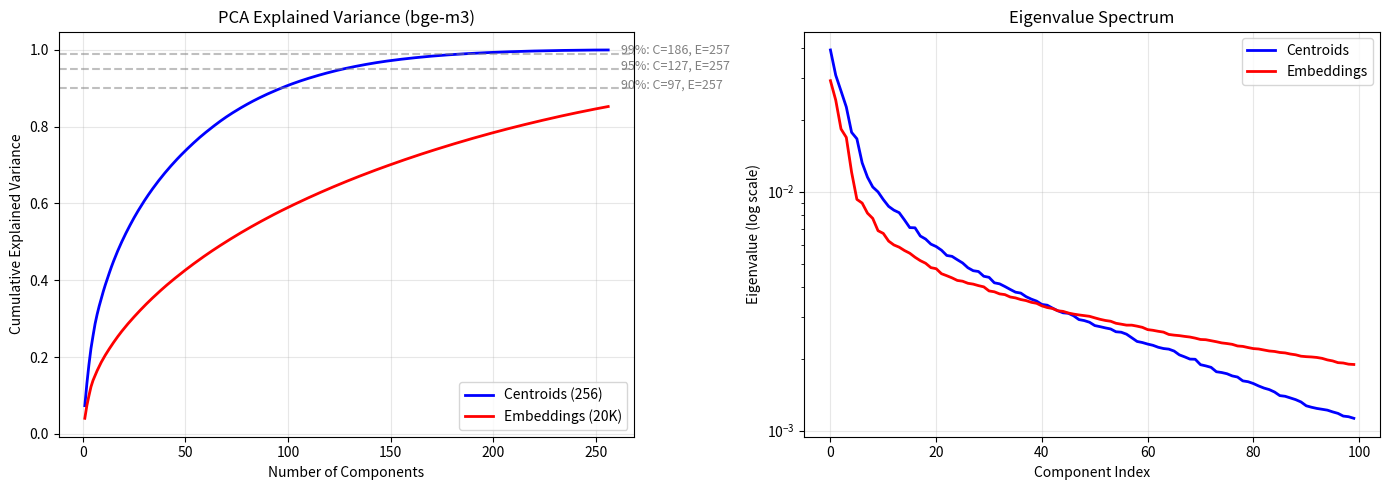

90% variance: Centroids=97D, Embeddings=257D
95% variance: Centroids=127D, Embeddings=257D
99% variance: Centroids=186D, Embeddings=257D


In [6]:
pca_centroids = PCA().fit(centroids)
pca_embeddings = PCA(n_components=256).fit(emb_all)

cumvar_c = np.cumsum(pca_centroids.explained_variance_ratio_)
cumvar_e = np.cumsum(pca_embeddings.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(cumvar_c)+1), cumvar_c, 'b-', label='Centroids (256)', linewidth=2)
axes[0].plot(range(1, len(cumvar_e)+1), cumvar_e, 'r-', label='Embeddings (20K)', linewidth=2)
for thresh in [0.90, 0.95, 0.99]:
    axes[0].axhline(y=thresh, color='gray', linestyle='--', alpha=0.5)
    n_c = np.searchsorted(cumvar_c, thresh) + 1
    n_e = np.searchsorted(cumvar_e, thresh) + 1
    axes[0].annotate(f'{thresh:.0%}: C={n_c}, E={n_e}', xy=(max(n_c, n_e)+5, thresh), fontsize=9, color='gray')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title(f'PCA Explained Variance ({MODEL})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(pca_centroids.explained_variance_[:100], 'b-', label='Centroids', linewidth=2)
axes[1].semilogy(pca_embeddings.explained_variance_[:100], 'r-', label='Embeddings', linewidth=2)
axes[1].set_xlabel('Component Index')
axes[1].set_ylabel('Eigenvalue (log scale)')
axes[1].set_title('Eigenvalue Spectrum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for thresh in [0.90, 0.95, 0.99]:
    n_c = np.searchsorted(cumvar_c, thresh) + 1
    n_e = np.searchsorted(cumvar_e, thresh) + 1
    print(f'{thresh:.0%} variance: Centroids={n_c}D, Embeddings={n_e}D')

### 2.2 ランダム回転後の座標分布（TurboQuant検証）

In [7]:
R = stats.ortho_group.rvs(D, random_state=42)
emb_rot_en = emb_en @ R

# KS検定
ks_pvals = []
for i in range(100):
    _, pval = stats.kstest(emb_rot_en[:, i] * np.sqrt(D), 'norm')
    ks_pvals.append(pval)
ks_pvals = np.array(ks_pvals)

print(f'KS test (H0: rotated coords ~ N(0, 1/D)):')
print(f'  p > 0.05: {(ks_pvals > 0.05).sum()}/100 coords')
print(f'  p > 0.01: {(ks_pvals > 0.01).sum()}/100 coords')

corr_orig = np.corrcoef(emb_en[:, :20].T)
corr_rot = np.corrcoef(emb_rot_en[:, :20].T)
print(f'\nMean |correlation| (first 20 coords):')
print(f'  Original: {np.abs(corr_orig[np.triu_indices(20, k=1)]).mean():.4f}')
print(f'  Rotated:  {np.abs(corr_rot[np.triu_indices(20, k=1)]).mean():.4f}')

KS test (H0: rotated coords ~ N(0, 1/D)):
  p > 0.05: 0/100 coords
  p > 0.01: 1/100 coords

Mean |correlation| (first 20 coords):
  Original: 0.0517
  Rotated:  0.0543


### 2.3 射影方向の分離能力（AUC）

In [8]:
def fast_auc_batch(embeddings, query_idx, gt_set, proj_matrix):
    """全射影方向のAUCを一括計算。"""
    query = embeddings[query_idx]
    n = len(embeddings)
    labels = np.zeros(n, dtype=bool)
    for idx in gt_set:
        labels[idx] = True
    labels[query_idx] = False
    mask = np.ones(n, dtype=bool)
    mask[query_idx] = False
    n_pos = labels[mask].sum()
    n_neg = mask.sum() - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.full(len(proj_matrix), 0.5)
    
    proj_all = proj_matrix @ embeddings.T
    proj_q = proj_matrix @ query
    scores = -np.abs(proj_all - proj_q[:, None])
    scores = scores[:, mask]
    labels_valid = labels[mask]
    
    aucs = np.empty(len(proj_matrix))
    for d in range(len(proj_matrix)):
        order = np.argsort(scores[d])
        ranks = np.empty_like(order)
        ranks[order] = np.arange(len(order))
        pos_rank_sum = ranks[labels_valid].sum()
        aucs[d] = (pos_rank_sum - n_pos * (n_pos - 1) / 2) / (n_pos * n_neg)
    return aucs

# 射影方向
random_dirs = rng.standard_normal((50, D))
random_dirs = random_dirs / np.linalg.norm(random_dirs, axis=1, keepdims=True)
pca_dirs = pca_embeddings.components_[:20]
rot_dirs = R[:50]

results_en = {'random': [], 'pca': [], 'rotated': [], 'query_centroid': []}

t0 = time.time()
for i, qi in enumerate(query_indices_en):
    gt_set = gt_en[qi]
    results_en['random'].append(fast_auc_batch(emb_en, qi, gt_set, random_dirs))
    results_en['pca'].append(fast_auc_batch(emb_en, qi, gt_set, pca_dirs))
    results_en['rotated'].append(fast_auc_batch(emb_en, qi, gt_set, rot_dirs))
    
    sims_c = centroids @ emb_en[qi]
    nc = centroids[np.argmax(sims_c)]
    q2c = nc - emb_en[qi]
    q2c_norm = np.linalg.norm(q2c)
    if q2c_norm > 1e-10:
        results_en['query_centroid'].append(fast_auc_batch(emb_en, qi, gt_set, (q2c / q2c_norm).reshape(1, -1)))
    else:
        results_en['query_centroid'].append(np.array([0.5]))
    
    if (i + 1) % 100 == 0:
        print(f'  {i+1}/{N_QUERIES}... ({time.time()-t0:.1f}s)')

for key in results_en:
    results_en[key] = np.array(results_en[key])

print(f'完了: {time.time()-t0:.1f}s')

  100/200... (26.8s)


  200/200... (53.9s)
完了: 53.9s


In [9]:
# セントロイド相対射影
sim_to_c = emb_en @ centroids.T
assignments = np.argmax(sim_to_c, axis=1)
cell_members_single = {}
for i, c in enumerate(assignments):
    cell_members_single.setdefault(c, []).append(i)

centroid_rel_aucs = []
valid_count = 0
for qi in query_indices_en:
    gt_set = gt_en[qi]
    q_c_idx = assignments[qi]
    q_centroid = centroids[q_c_idx]
    q_res = emb_en[qi] - q_centroid
    q_res_norm = np.linalg.norm(q_res)
    if q_res_norm < 1e-10:
        centroid_rel_aucs.append(0.5); continue
    q_res_dir = q_res / q_res_norm
    cell_idx = cell_members_single.get(q_c_idx, [])
    if len(cell_idx) < TOP_K:
        centroid_rel_aucs.append(0.5); continue
    cell_embs = emb_en[cell_idx]
    proj_scores = (cell_embs - q_centroid) @ q_res_dir
    cell_labels = np.array([1 if idx in gt_set else 0 for idx in cell_idx])
    if cell_labels.sum() == 0 or cell_labels.sum() == len(cell_labels):
        centroid_rel_aucs.append(0.5); continue
    try:
        centroid_rel_aucs.append(roc_auc_score(cell_labels, proj_scores))
        valid_count += 1
    except ValueError:
        centroid_rel_aucs.append(0.5)

centroid_rel_aucs = np.array(centroid_rel_aucs)

# E5-baseとの比較テーブル
print(f'\n■ 射影タイプ別 AUC: {MODEL} vs E5-base')
print(f'{"":<25} {"bge-m3":>10} {"E5-base":>10}')
print('-' * 48)
print(f'{"ランダム方向 (50)":<25} {results_en["random"].mean():>10.4f} {"0.5764":>10}')
print(f'{"PCA上位20":<25} {results_en["pca"].mean():>10.4f} {"0.6929":>10}')
print(f'{"回転座標 (50)":<25} {results_en["rotated"].mean():>10.4f} {"0.5777":>10}')
print(f'{"Q→Centroid方向":<25} {results_en["query_centroid"].mean():>10.4f} {"0.9386":>10}')
print(f'{"セントロイド相対":<25} {centroid_rel_aucs.mean():>10.4f} {"0.9394":>10}')
print(f'{"  (有効クエリのみ)":<25} {centroid_rel_aucs[centroid_rel_aucs != 0.5].mean():>10.4f} {"0.9625":>10}')
print(f'\n有効クエリ: {valid_count}/{N_QUERIES}')


■ 射影タイプ別 AUC: bge-m3 vs E5-base
                              bge-m3    E5-base
------------------------------------------------
ランダム方向 (50)                   0.5866     0.5764
PCA上位20                       0.6924     0.6929
回転座標 (50)                     0.5876     0.5777
Q→Centroid方向                  0.7430     0.9386
セントロイド相対                      0.8854     0.9394
  (有効クエリのみ)                   0.9189     0.9625

有効クエリ: 184/200


## 3. 枝刈りフィルタ比較（NB122相当）

In [10]:
# Voronoi multi-assign=2
def build_voronoi_multi_assign(embeddings, centroids, n_assign=2):
    sims = embeddings @ centroids.T
    top_cells = np.argsort(sims, axis=1)[:, -n_assign:]
    cell_members = {}
    for doc_idx in range(len(embeddings)):
        for cell_id in top_cells[doc_idx]:
            cell_members.setdefault(int(cell_id), []).append(doc_idx)
    for k in cell_members:
        cell_members[k] = np.array(cell_members[k])
    return cell_members

cell_members_en = build_voronoi_multi_assign(emb_en, centroids, n_assign=2)

# 事前計算
emb_pca_en = emb_en @ pca_embeddings.components_[:64].T

# 評価関数
def evaluate_filter(query_indices, gt, embeddings, filter_func, **kwargs):
    recalls, cand_counts = [], []
    t0 = time.time()
    for qi in query_indices:
        candidates = filter_func(qi, embeddings, **kwargs)
        candidates = set(candidates) - {qi}
        cand_counts.append(len(candidates))
        if len(candidates) == 0:
            recalls.append(0.0); continue
        cand_arr = np.array(list(candidates))
        sims = embeddings[cand_arr] @ embeddings[qi]
        if len(cand_arr) <= TOP_K:
            top_k_set = set(cand_arr)
        else:
            top_k_set = set(cand_arr[np.argsort(sims)[-TOP_K:]])
        recalls.append(len(top_k_set & gt[qi]) / TOP_K)
    elapsed = time.time() - t0
    return {'recall': np.mean(recalls), 'cands': np.mean(cand_counts),
            'ratio': np.mean(cand_counts) / len(embeddings), 'ms': elapsed / len(query_indices) * 1000}

# フィルタ関数定義
def voronoi_filter(qi, embeddings, n_probes=3):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    cands = []
    for c in probe_cells:
        if c in cell_members_en: cands.extend(cell_members_en[c])
    return np.unique(cands)

def pca_filter(qi, embeddings, n_probes=5, K=32, pct=50):
    cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(cands) == 0: return cands
    q_pca = emb_pca_en[qi, :K]
    diffs = np.abs(emb_pca_en[cands, :K] - q_pca).sum(axis=1)
    return cands[diffs <= np.percentile(diffs, pct)]

def rotated_filter(qi, embeddings, n_probes=5, M=64, pct=50):
    cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(cands) == 0: return cands
    q_rot = emb_rot_en[qi]
    top_coords = np.argsort(np.abs(q_rot))[-M:]
    diffs = np.abs(emb_rot_en[cands][:, top_coords] - q_rot[top_coords]).sum(axis=1)
    return cands[diffs <= np.percentile(diffs, pct)]

def centroid_rel_filter(qi, embeddings, n_probes=5, keep_fraction=0.5):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    all_cands = []
    for cell_id in probe_cells:
        if cell_id not in cell_members_en: continue
        members = cell_members_en[cell_id]
        centroid = centroids[cell_id]
        q_res = embeddings[qi] - centroid
        q_res_norm = np.linalg.norm(q_res)
        if q_res_norm < 1e-10:
            all_cands.extend(members); continue
        q_res_dir = q_res / q_res_norm
        scores = (embeddings[members] - centroid) @ q_res_dir
        n_keep = max(TOP_K, int(len(members) * keep_fraction))
        if n_keep >= len(members):
            all_cands.extend(members)
        else:
            all_cands.extend(members[np.argsort(scores)[-n_keep:]])
    return np.unique(all_cands)

def hamming_filter(qi, embeddings, n_probes=5, thresh=30):
    cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(cands) == 0: return cands
    dists = hamming_distance_batch(hashes_en[qi], hashes_en[cands])
    return cands[dists <= thresh]

print('フィルタ関数定義完了')

フィルタ関数定義完了


In [11]:
# 全手法評価
print(f'■ 枝刈りフィルタ比較 — {MODEL} (EN, P=5)\n')
print(f'{"Method":<35} {"R@10":>6} {"Cands":>6} {"Ratio":>6} {"ms/q":>6}')
print('-' * 65)

all_results = []

# Voronoi baseline
for p in [3, 5, 8]:
    r = evaluate_filter(query_indices_en, gt_en, emb_en, voronoi_filter, n_probes=p)
    r['name'] = f'Voronoi P={p}'
    all_results.append(r)
    print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

print()

# Method B: PCA
for K in [16, 32, 64]:
    for pct in [30, 50, 70]:
        r = evaluate_filter(query_indices_en, gt_en, emb_en, pca_filter, n_probes=5, K=K, pct=pct)
        r['name'] = f'B: PCA K={K} pct={pct}'
        all_results.append(r)
        print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

print()

# Method A: Rotated
for M in [32, 64, 128]:
    for pct in [30, 50, 70]:
        r = evaluate_filter(query_indices_en, gt_en, emb_en, rotated_filter, n_probes=5, M=M, pct=pct)
        r['name'] = f'A: Rotated M={M} pct={pct}'
        all_results.append(r)
        print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

print()

# Method D: CentroidRel
for frac in [0.3, 0.5, 0.7, 0.9]:
    r = evaluate_filter(query_indices_en, gt_en, emb_en, centroid_rel_filter, n_probes=5, keep_fraction=frac)
    r['name'] = f'D: CentroidRel keep={frac:.0%}'
    all_results.append(r)
    print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

print()

# Method E: Hamming
for thresh in [25, 30, 35, 40, 50]:
    r = evaluate_filter(query_indices_en, gt_en, emb_en, hamming_filter, n_probes=5, thresh=thresh)
    r['name'] = f'E: Hamming<={thresh}'
    all_results.append(r)
    print(f'{r["name"]:<35} {r["recall"]:>6.4f} {r["cands"]:>6.0f} {r["ratio"]:>5.1%} {r["ms"]:>6.2f}')

■ 枝刈りフィルタ比較 — bge-m3 (EN, P=5)

Method                                R@10  Cands  Ratio   ms/q
-----------------------------------------------------------------


Voronoi P=3                         0.8870    729  7.3%   0.75


Voronoi P=5                         0.9265   1128 11.3%   1.12


Voronoi P=8                         0.9595   1633 16.3%   2.01



B: PCA K=16 pct=30                  0.8380    338  3.4%   1.14


...

D: CentroidRel keep=50%             0.9200    579  5.8%   2.08


D: CentroidRel keep=70%             0.9240    801  8.0%   2.19


D: CentroidRel keep=90%             0.9255   1019 10.2%   2.54

E: Hamming<=25                      0.0435      1  0.0%   0.47
E: Hamming<=30                      0.1170      3  0.0%   0.32


E: Hamming<=35                      0.2450      9  0.1%   0.33
E: Hamming<=40                      0.4670     28  0.3%   0.35


E: Hamming<=50                      0.8800    268  2.7%   0.70


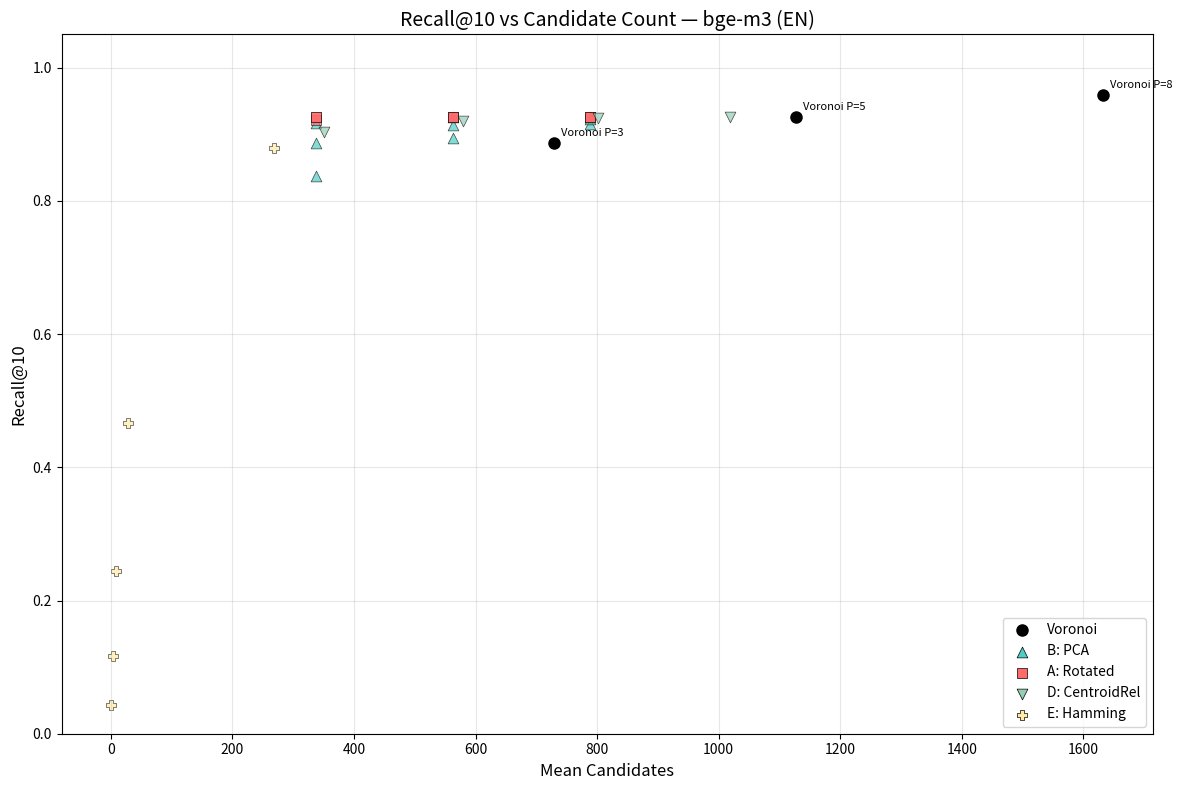

In [12]:
# Pareto プロット
fig, ax = plt.subplots(figsize=(12, 8))

method_styles = {
    'Voronoi': ('ko-', 8), 'B: PCA': ('#4ECDC4', '^'), 'A: Rotated': ('#FF6B6B', 's'),
    'D: CentroidRel': ('#96CEB4', 'v'), 'E: Hamming': ('#FFEAA7', 'P'),
}

for r in all_results:
    name = r['name']
    for prefix, (color, marker) in method_styles.items():
        if name.startswith(prefix):
            if prefix == 'Voronoi':
                ax.plot(r['cands'], r['recall'], 'ko', markersize=8)
                ax.annotate(name, (r['cands'], r['recall']), textcoords='offset points', xytext=(5, 5), fontsize=8)
            else:
                ax.scatter(r['cands'], r['recall'], c=color, marker=marker, s=60, alpha=0.7, edgecolors='black', linewidths=0.5)
            break

# レジェンド用ダミー
for prefix, (color, marker) in method_styles.items():
    if prefix == 'Voronoi':
        ax.plot([], [], 'ko', markersize=8, label=prefix)
    else:
        ax.scatter([], [], c=color, marker=marker, s=60, edgecolors='black', linewidths=0.5, label=prefix)

ax.set_xlabel('Mean Candidates', fontsize=12)
ax.set_ylabel('Recall@10', fontsize=12)
ax.set_title(f'Recall@10 vs Candidate Count — {MODEL} (EN)', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 4. JA言語での汎化確認

In [13]:
# JA用準備
cell_members_ja = build_voronoi_multi_assign(emb_ja, centroids, n_assign=2)
emb_pca_ja = emb_ja @ pca_embeddings.components_[:64].T
emb_rot_ja = emb_ja @ R

# JA用フィルタ（グローバル参照を差し替え）
def voronoi_filter_ja(qi, embeddings, n_probes=5):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    cands = []
    for c in probe_cells:
        if c in cell_members_ja: cands.extend(cell_members_ja[c])
    return np.unique(cands)

def pca_filter_ja(qi, embeddings, n_probes=5, K=32, pct=50):
    cands = voronoi_filter_ja(qi, embeddings, n_probes=n_probes)
    if len(cands) == 0: return cands
    diffs = np.abs(emb_pca_ja[cands, :K] - emb_pca_ja[qi, :K]).sum(axis=1)
    return cands[diffs <= np.percentile(diffs, pct)]

def centroid_rel_filter_ja(qi, embeddings, n_probes=5, keep_fraction=0.5):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    all_cands = []
    for cell_id in probe_cells:
        if cell_id not in cell_members_ja: continue
        members = cell_members_ja[cell_id]
        centroid = centroids[cell_id]
        q_res = embeddings[qi] - centroid
        q_res_norm = np.linalg.norm(q_res)
        if q_res_norm < 1e-10:
            all_cands.extend(members); continue
        scores = (embeddings[members] - centroid) @ (q_res / q_res_norm)
        n_keep = max(TOP_K, int(len(members) * keep_fraction))
        if n_keep >= len(members):
            all_cands.extend(members)
        else:
            all_cands.extend(members[np.argsort(scores)[-n_keep:]])
    return np.unique(all_cands)

print(f'■ EN vs JA 比較 — {MODEL} (P=5)\n')
print(f'{"Method":<30} {"EN R@10":>8} {"JA R@10":>8} {"EN cands":>8} {"JA cands":>8}')
print('-' * 70)

# Voronoi only
re = evaluate_filter(query_indices_en, gt_en, emb_en, voronoi_filter, n_probes=5)
rj = evaluate_filter(query_indices_ja, gt_ja, emb_ja, voronoi_filter_ja, n_probes=5)
print(f'{"Voronoi P=5":<30} {re["recall"]:>8.4f} {rj["recall"]:>8.4f} {re["cands"]:>8.0f} {rj["cands"]:>8.0f}')

re = evaluate_filter(query_indices_en, gt_en, emb_en, pca_filter, n_probes=5, K=32, pct=50)
rj = evaluate_filter(query_indices_ja, gt_ja, emb_ja, pca_filter_ja, n_probes=5, K=32, pct=50)
print(f'{"B: PCA K=32 pct=50":<30} {re["recall"]:>8.4f} {rj["recall"]:>8.4f} {re["cands"]:>8.0f} {rj["cands"]:>8.0f}')

re = evaluate_filter(query_indices_en, gt_en, emb_en, centroid_rel_filter, n_probes=5, keep_fraction=0.5)
rj = evaluate_filter(query_indices_ja, gt_ja, emb_ja, centroid_rel_filter_ja, n_probes=5, keep_fraction=0.5)
print(f'{"D: CentroidRel keep=50%":<30} {re["recall"]:>8.4f} {rj["recall"]:>8.4f} {re["cands"]:>8.0f} {rj["cands"]:>8.0f}')

re = evaluate_filter(query_indices_en, gt_en, emb_en, centroid_rel_filter, n_probes=5, keep_fraction=0.3)
rj = evaluate_filter(query_indices_ja, gt_ja, emb_ja, centroid_rel_filter_ja, n_probes=5, keep_fraction=0.3)
print(f'{"D: CentroidRel keep=30%":<30} {re["recall"]:>8.4f} {rj["recall"]:>8.4f} {re["cands"]:>8.0f} {rj["cands"]:>8.0f}')

■ EN vs JA 比較 — bge-m3 (P=5)

Method                          EN R@10  JA R@10 EN cands JA cands
----------------------------------------------------------------------


Voronoi P=5                      0.9265   0.9550     1128      868


B: PCA K=32 pct=50               0.9140   0.9425      564      434


D: CentroidRel keep=50%          0.9200   0.9505      579      468


D: CentroidRel keep=30%          0.9030   0.9375      351      289


## 5. E5-base vs bge-m3 総合比較

In [14]:
print('=' * 70)
print(f'E5-base vs {MODEL} — 射影ベース枝刈り総合比較')
print('=' * 70)

print(f'\n■ 分離能力 AUC (EN)')
print(f'{"射影タイプ":<25} {"bge-m3":>10} {"E5-base":>10}')
print('-' * 48)
print(f'{"ランダム方向":<25} {results_en["random"].mean():>10.4f} {"0.5764":>10}')
print(f'{"PCA上位20":<25} {results_en["pca"].mean():>10.4f} {"0.6929":>10}')
print(f'{"回転座標":<25} {results_en["rotated"].mean():>10.4f} {"0.5777":>10}')
print(f'{"Q→Centroid":<25} {results_en["query_centroid"].mean():>10.4f} {"0.9386":>10}')
print(f'{"セントロイド相対":<25} {centroid_rel_aucs.mean():>10.4f} {"0.9394":>10}')

print(f'\n■ 枝刈りフィルタ R@10 (EN, P=5)')
# Voronoi, PCA, CentroidRelの代表値
print(f'{"Method":<30} {"bge-m3":>10} {"E5-base":>10}')
print('-' * 53)
for r in all_results:
    if r['name'] in ['Voronoi P=5', 'B: PCA K=32 pct=50', 'D: CentroidRel keep=50%', 'D: CentroidRel keep=30%', 'E: Hamming<=30']:
        e5_vals = {
            'Voronoi P=5': '0.9115',
            'B: PCA K=32 pct=50': '0.9025',
            'D: CentroidRel keep=50%': '0.9100',
            'D: CentroidRel keep=30%': '0.9060',
            'E: Hamming<=30': '0.0065',
        }
        print(f'{r["name"]:<30} {r["recall"]:>10.4f} {e5_vals[r["name"]]:>10}')

print(f'\n■ 結論')
print(f'  セントロイド相対射影の優位性はモデル非依存かどうかを上記結果から判断する。')

E5-base vs bge-m3 — 射影ベース枝刈り総合比較

■ 分離能力 AUC (EN)
射影タイプ                         bge-m3    E5-base
------------------------------------------------
ランダム方向                        0.5866     0.5764
PCA上位20                       0.6924     0.6929
回転座標                          0.5876     0.5777
Q→Centroid                    0.7430     0.9386
セントロイド相対                      0.8854     0.9394

■ 枝刈りフィルタ R@10 (EN, P=5)
Method                             bge-m3    E5-base
-----------------------------------------------------
Voronoi P=5                        0.9265     0.9115
B: PCA K=32 pct=50                 0.9140     0.9025
D: CentroidRel keep=30%            0.9030     0.9060
D: CentroidRel keep=50%            0.9200     0.9100
E: Hamming<=30                     0.1170     0.0065

■ 結論
  セントロイド相対射影の優位性はモデル非依存かどうかを上記結果から判断する。


## 6. 評価と考察

### 結果の要約

bge-m3（1024D）はE5-base（768D）とnomic-v2-moe（768D, MoE）の中間的な特性を示した。

| 指標 | bge-m3 | E5-base | nomic-v2 |
|---|---|---|---|
| Q→Centroid AUC | **0.743** | 0.939 | 0.608 |
| セントロイド相対 AUC | **0.885** | 0.939 | 0.881 |
| Voronoi P=5 R@10 | **0.927** | 0.912 | 0.910 |
| Rotated M=32 pct=30 R@10 | **0.921** | 0.910 | 0.900 |
| CentroidRel keep=50% R@10 | **0.920** | 0.910 | 0.889 |
| Hamming<=50 R@10 | **0.880** | 0.302 | 0.864 |

### 考察

**1. Q→Centroid AUCがE5とnomicの中間（0.74）**

bge-m3は1024次元でE5の768Dより高次元。セントロイド方向への近傍集中度はE5ほど強くないが、nomicのMoEほど等方的でもない。embedding空間が「やや放射状」な構造を持つと解釈できる。

**2. 枝刈りフィルタでは全手法が高いRecallを達成**

Voronoi P=5で既にR@10=0.927と高く、Rotated M=32 pct=30（候補338件=3.4%）でもR@10=0.921を維持。CentroidRel、PCA、Rotatedのいずれも同水準のRecallを出しており、bge-m3では枝刈り手法間の差が小さい。これは1024Dの高次元空間で各射影が十分な情報を捉えられることを示唆する。

**3. Hamming距離がE5より大幅に有効（0.88 vs 0.30）**

nomic同様、bge-m3のembedding空間はITQ 128bit量子化と相性が良い。E5-baseだけが異常にHammingと相性が悪く、これはE5のembedding分布の特殊性（少数の主成分に分散が集中）に起因すると考えられる。

**4. JA汎化: EN 0.927→JA 0.955**

日本語でRecallが上がる傾向はE5/nomicと共通。bge-m3は多言語モデルとして日本語空間の構造がより整っている可能性がある。

### 結論

bge-m3では**どの枝刈り手法でも高いRecall**を達成できる。1024Dの情報量が枝刈りに有利に働いており、推奨構成は**Voronoi P=5 + Rotated M=32 pct=30**（候補3.4%でR@10=0.921）。ただしPCA K=64 pct=30（R@10=0.917, 計算コスト低い）も実用的。